# Data Preparation

In this section, we aim to gain a deeper understanding of the dataset. For a more streamlined, code-centric process, please refer to the first notebook, which is designed with a class-oriented approach and guides you through the steps required for complex production scenarios.

### 🐍 Create an MLTable file using Python

In this step, we register the CSV file into our environment. This allows you to efficiently track, manage, and utilize the dataset throughout your workflow.

In [2]:
import mltable
from mltable import DataType
from dotenv import load_dotenv
import os
import time
from azure.ai.ml import MLClient
from azure.ai.ml.entities import Data
from azure.ai.ml.constants import AssetTypes
from azure.identity import DefaultAzureCredential

import pandas as pd

In [3]:
# Create a table from this file
paths = [{"file": "../data/raw/data_call_center.csv"}]

# Create a table from the data_call_center.csv file.
# In this case, we don't want to infer the column types so that we can set them manually.
# This is just for demonstration purposes. In most cases, you can just let MLTable infer the column types.
tbl = mltable.from_delimited_files(paths, infer_column_types=False)

# Set the column types.
# We can use the DataType.to_*() functions to convert the column types
column_types = {
    "contract_number": DataType.to_int(),
    "occurrence_number": DataType.to_int(),
    "closure_login": DataType.to_string(),
    "occurrence_type_ID": DataType.to_int(),
    "occurrence_date": DataType.to_string(),
    "closure_date": DataType.to_string(),
    "internal_sla_end_date": DataType.to_string(),
    "closure_reason": DataType.to_string(),
    "subcampaign_code": DataType.to_int(),
    "operator_name": DataType.to_string(),
}
tbl = tbl.convert_column_types(column_types)

# display the first 5 rows of the table
tbl.show(5)

,contract_number,occurrence_number,closure_login,occurrence_type_ID,occurrence_date,closure_date,internal_sla_end_date,closure_reason,subcampaign_code,operator_name
0,1003403,1031390591,F252641,1494,2024-10-23 10:10:59.000,2024-10-23 10:11:36.000,2024-10-26 23:59:59.000,ME NAO GERADA - AREA NAO CABEADA/PRODUTO INDIS...,1920,FOZ DO IGUACU
1,374091261,1032593626,F271480,1484,2024-10-29 16:21:12.000,2024-10-29 16:25:20.000,2024-11-05 18:21:12.000,NAO LIBERADO - SEM REDE,1918,LONDRINA
2,412875230,1033614136,F271479,1484,2024-11-04 09:30:53.000,2024-11-04 09:40:12.000,2024-11-09 11:30:53.000,QUEDA DE LIGACAO,1918,SANTA MARIA
3,366791371,1037228089,F258672,1484,2024-11-28 14:49:10.000,2024-11-28 14:56:54.000,2024-12-04 16:49:10.000,ENDERECO LIBERADO,1918,JOINVILLE
4,1060725,1038234179,F257446,1484,2024-12-05 16:52:05.000,2024-12-05 17:02:16.000,2024-12-11 18:52:05.000,ENDERECO LIBERADO,1918,ITAJUBA


#### 💾 Save the data loading steps to an MLTable file

You can save the data loading steps into an `MLTable` file so that you or a team member can - at a later point in time - load the data into a pandas data frame by using :

```python
mltable.load("<folder_containing_MLTable_file>")
```


In [26]:
# save the MLTable to local disk - in the same directory as the titanic.csv file
tbl.save("../data/raw", overwrite=True)

paths:
- file: file://c:\Users\karinaa\OneDrive - Microsoft\Documents\codes\call_center_brasil_center\data\raw\data_call_center.csv
transformations:
- read_delimited:
    delimiter: ','
    empty_as_string: false
    encoding: utf8
    header: all_files_same_headers
    include_path_column: false
    infer_column_types: false
    partition_size: 20971520
    path_column: Path
    support_multi_line: false
- convert_column_types:
  - column_type: int
    columns: contract_number
  - column_type: int
    columns: occurrence_number
  - column_type: string
    columns: closure_login
  - column_type: int
    columns: occurrence_type_ID
  - column_type: string
    columns: occurrence_date
  - column_type: string
    columns: closure_date
  - column_type: string
    columns: internal_sla_end_date
  - column_type: string
    columns: closure_reason
  - column_type: int
    columns: subcampaign_code
  - column_type: string
    columns: operator_name
type: mltable

### 🤝 Create a data asset to aid sharing and reproducibility

Your data (including the `MLTable` file) is currently saved on disk, making it hard to share with Team members. By creating a *data asset* in AzureML, your data will be uploaded to cloud storage and "bookmarked", meaning your Team members can access the MLTable using a friendly name. Also, the data asset is *versioned*.

In [4]:
load_dotenv()
subscription_id = os.environ.get("subscription")
resource_group = os.environ.get("resource_group")
workspace = os.environ.get("workspace")

In [ ]:
# set the version number of the data asset to the current UTC time
VERSION = time.strftime("%Y.%m.%d.%H%M%S", time.gmtime())

# connect to the AzureML workspace
ml_client = MLClient(
    DefaultAzureCredential(), subscription_id, resource_group, workspace
)

# create the data asset object
my_data = Data(
    path="../data/raw",
    type=AssetTypes.MLTABLE,
    description="Call Center Data",
    name="call_center_data",
    version=VERSION,
)

# create the data asset in your workspace
ml_client.data.create_or_update(my_data)

By saving our data using MLTable, we unlock the ability to effortlessly explore, analyze, and extract key insights and statistics from our dataset without any additional steps.

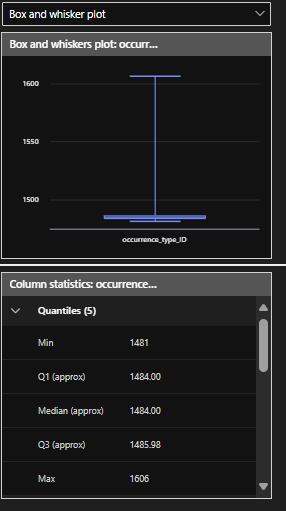

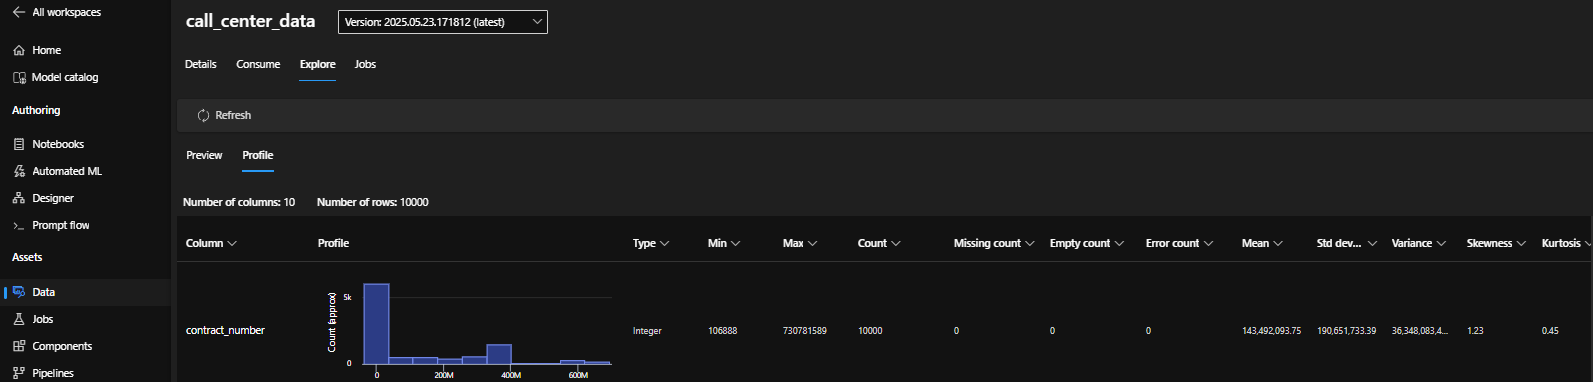

## Cleaning the data

In [5]:
# Loading back our saved MLTable
ml_client = MLClient(
    DefaultAzureCredential(), subscription_id, resource_group, workspace
)

data_asset = ml_client.data.get("call_center_data", version="2025.05.23.171812")

tbl = mltable.load(data_asset.path)

df = tbl.to_pandas_dataframe()

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415901 entries, 0 to 415900
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   contract_number        415901 non-null  int64 
 1   occurrence_number      415901 non-null  int64 
 2   closure_login          383026 non-null  object
 3   occurrence_type_ID     415901 non-null  int64 
 4   occurrence_date        415901 non-null  object
 5   closure_date           400444 non-null  object
 6   internal_sla_end_date  415901 non-null  object
 7   closure_reason         400444 non-null  object
 8   subcampaign_code       415901 non-null  int64 
 9   operator_name          415901 non-null  object
dtypes: int64(4), object(6)
memory usage: 31.7+ MB


### Removing id informations - no need to keep them

In [7]:
df[df.duplicated()]

,contract_number,occurrence_number,closure_login,occurrence_type_ID,occurrence_date,closure_date,internal_sla_end_date,closure_reason,subcampaign_code,operator_name


In [8]:
df_processed = df.drop(
    columns=[
        "contract_number",
        "occurrence_number",
        "closure_login",
        "occurrence_type_ID",
        "internal_sla_end_date",
    ]
)

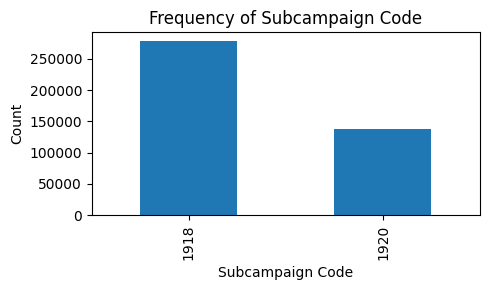

In [9]:
import matplotlib.pyplot as plt

df_processed["subcampaign_code"].value_counts().plot(kind="bar", figsize=(5, 3))
plt.xlabel("Subcampaign Code")
plt.ylabel("Count")
plt.title("Frequency of Subcampaign Code")
plt.tight_layout()
plt.show()

In [10]:
df_processed.drop(columns=["subcampaign_code"], inplace=True)

## Converting the dates to datetime

In [11]:
df_processed["occurrence_date"] = pd.to_datetime(
    df_processed["occurrence_date"], format="%Y-%m-%d %H:%M:%S.%f"
)
df_processed["closure_date"] = pd.to_datetime(
    df_processed["closure_date"],
    format="%Y-%m-%d %H:%M:%S.%f",
)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415901 entries, 0 to 415900
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   contract_number        415901 non-null  int64 
 1   occurrence_number      415901 non-null  int64 
 2   closure_login          383026 non-null  object
 3   occurrence_type_ID     415901 non-null  int64 
 4   occurrence_date        415901 non-null  object
 5   closure_date           400444 non-null  object
 6   internal_sla_end_date  415901 non-null  object
 7   closure_reason         400444 non-null  object
 8   subcampaign_code       415901 non-null  int64 
 9   operator_name          415901 non-null  object
dtypes: int64(4), object(6)
memory usage: 31.7+ MB


In [13]:
# min date with no closure date
df_processed[df_processed["closure_date"].isnull()]["occurrence_date"].min()

Timestamp('2024-01-01 08:23:12')

In [14]:
df_processed[df_processed["closure_date"].isnull()]["occurrence_date"]

77       2024-02-17 15:14:44
80       2024-06-24 15:55:10
95       2024-03-16 08:55:02
97       2024-06-27 18:36:28
109      2024-03-18 12:08:04
                 ...        
415589   2025-05-19 22:12:52
415713   2025-05-12 17:46:10
415743   2025-04-26 10:31:53
415747   2025-04-26 10:20:57
415815   2025-05-19 22:27:13
Name: occurrence_date, Length: 15457, dtype: datetime64[ns]

In [126]:
# Fill null closure_date with current date plus 30 days.
# For cases where the closure_date is missing (i.e., unresolved issues),
# we assign a pseudo closure_date—current date + 30 days. This effectively
# gives a heavier "weight" to these unresolved records in subsequent analysis,
# for example when calculating resolution times, as they will appear to take longer
# to resolve.

In [15]:
df_processed.loc[df_processed["closure_date"].isnull(), "closure_date"] = (
    pd.Timestamp.today() + pd.Timedelta(days=30)
)

### Create a new column 'time_to_resolve' (in hours) as the difference between closure_date and occurrence_date.


In [16]:
# Note: This feature is only available in historical data where closure_date is known.
df_processed["time_to_resolve"] = (
    df_processed["closure_date"] - df_processed["occurrence_date"]
).dt.total_seconds() / 3600

In [17]:
df_processed.loc[df_processed["closure_reason"].isnull(), "closure_reason"] = "Unknown"

### Understanding the closure reason

In [ ]:
print(df_processed["closure_reason"].value_counts().to_string())

Given that the dataset contains multiple unique closure reasons, we will apply a technique to consolidate them into a few broader categories. Note that this is just a demo—there are many approaches to handling categorical data, and tools like Azure Machine Learning's AutoML can handle much of the preprocessing automatically.


In [19]:
def group_reason(reason):
    # Standardize to uppercase to ease comparisons
    value = reason.upper().strip()

    # If exactly "DESISTENCIA", return as "Desistência"
    if value == "DESISTENCIA":
        return "desistencia"
    # Validate TIMEOUT (can be unique)
    if "TIMEOUT" in value:
        return "timeout"
    # If it contains "ME NAO GERADA", group as "ME Não Gerada"
    if "ME NAO GERADA" in value:
        return "me_n_gerada"
    # If it contains "ME GERADA", group as "ME Gerada"
    if "ME GERADA" in value:
        return "me_gerada"
    # If it contains "NAO LIBERADO" (this must come before LIBERADO to avoid confusion)
    if "NAO LIBERADO" in value:
        return "n_liberado"
    # If it contains "LIBERADO" (without "NAO")
    if "LIBERADO" in value:
        return "liberado"
    # If it contains "ABERTURA" (e.g., "ABERTURA INDEVIDA", "ABERTURA DE CHAMADO", etc.)
    if "ABERTURA" in value:
        return "abertura"
    # If it contains "DIRECIONADO" (e.g., "DIRECIONADO PARA CORRECAO EM SISTEMA")
    if "DIRECIONADO" in value:
        return "direcionado"
    # If it contains "MUD" (e.g., "MUD N EFETUADA DESISTENCIA", "MUDANCA DE ENDERECO EFETUADA")
    if "MUD" in value:
        return "mudanca"
    # If it indicates an error or is an informative occurrence (optional – add other rules if necessary)
    if "ERRO" in value:
        return "erro"
    if "OCORRENCIA" in value:
        return "ocorrencia"
    # If it's "UNKNOWN" or doesn't match any of the above patterns, default to "Outros"
    if "UNKNOWN" in value:
        return "unknown"

    return value

In [20]:
df_processed["aux"] = df_processed["closure_reason"].apply(group_reason)

In [ ]:
df_processed["aux"].value_counts()

In [22]:
freq = df_processed["aux"].value_counts(normalize=True)

In [23]:
df_processed["grupo_reason_final"] = df_processed["aux"].apply(
    lambda x: x if freq[x] >= 0.001140 else "Outros"
)

In [ ]:
df_processed["grupo_reason_final"].value_counts()

In [25]:
import unicodedata

df_processed["grupo_reason_final"] = df_processed["grupo_reason_final"].apply(
    lambda x: unicodedata.normalize("NFKD", x)
    .encode("ASCII", "ignore")
    .decode("utf-8")
    .lower()
    .strip()
    .replace(" ", "_")
)

In [26]:
df_processed = pd.get_dummies(
    df_processed, columns=["grupo_reason_final"], prefix="closure"
)

In [27]:
df_processed.drop(columns=["aux", "closure_date", "closure_reason"], inplace=True)

In [28]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415901 entries, 0 to 415900
Data columns (total 18 columns):
 #   Column                                              Non-Null Count   Dtype         
---  ------                                              --------------   -----         
 0   occurrence_date                                     415901 non-null  datetime64[ns]
 1   operator_name                                       415901 non-null  object        
 2   time_to_resolve                                     415901 non-null  float64       
 3   closure_aberta_ca1-end_(tempo_de_contato_excedido)  415901 non-null  bool          
 4   closure_abertura                                    415901 non-null  bool          
 5   closure_desistencia                                 415901 non-null  bool          
 6   closure_direcionado                                 415901 non-null  bool          
 7   closure_liberado                                    415901 non-null  bool          

In [29]:
# Lets not use the operator name for now
df_processed.drop(columns=["operator_name"], inplace=True)

## Adjusting the Target Variable

In this section, we adjust the time series horizon to refine our analysis and improve model performance.

In [30]:
agg_dict = {
    "time_to_resolve": "mean",
    "closure_aberta_ca1-end_(tempo_de_contato_excedido)": "sum",
    "closure_abertura": "sum",
    "closure_desistencia": "sum",
    "closure_direcionado": "sum",
    "closure_liberado": "sum",
    "closure_mdu_encaminhado_para_vistoria": "sum",
    "closure_me_com_alteracao_de_pacote": "sum",
    "closure_me_gerada": "sum",
    "closure_me_n_gerada": "sum",
    "closure_n_liberado": "sum",
    "closure_outros": "sum",
    "closure_queda_de_ligacao": "sum",
    "closure_reencaminhado_para_vistoria": "sum",
    "closure_timeout": "sum",
    "closure_unknown": "sum",
}

First, we group the data by day using the occurrence date. We calculate the daily call count and aggregate other features by computing their mean (for time_to_resolve) or sum (for the remaining metrics). This daily summary enables effective trend analysis and further modeling steps.

In [31]:
# Group data by day using pd.Grouper (by occurrence_date)
daily_agg = df_processed.groupby(pd.Grouper(key="occurrence_date", freq="D")).agg(
    agg_dict
)

# Calculate the total number of calls each day.
daily_count = (
    df_processed.groupby(pd.Grouper(key="occurrence_date", freq="D"))
    .size()
    .rename("call_count")
)

# Merge aggregated features with daily call count.
daily_df_processed = daily_agg.join(daily_count)

In [32]:
# Reindex so that every day in the range appears (fill missing days with zeros)
all_dates = pd.date_range(
    start=daily_df_processed.index.min(), end=daily_df_processed.index.max(), freq="D"
)
daily_df_processed = daily_df_processed.reindex(all_dates, fill_value=0)
daily_df_processed.index.name = "date"

In [ ]:
# Plot the time series
filtered_data = daily_df_processed[daily_df_processed.index.year >= 2025]

plt.figure(figsize=(12, 6))
plt.plot(
    filtered_data.index,
    filtered_data["call_count"],
    marker="o",
    linestyle="-",
    label="Call Count",
)
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.title("Daily Call Count (Year ≥ 2025)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Our data seems to have a strong seasonality component

### Calculating the target

For every date d in the DataFrame (with the date as index), the target will be the sum of call_count over a 30‐day window starting at date d. In other words, for each day d, you'll get the accumulated call_count for the next 30 days (including day d).

In [34]:
# Since rolling windows in pandas are backward-looking,
# we reverse the DataFrame order and then apply a rolling window
# with a time span of "30D" (30 days). After that, we reverse the result back.
daily_df_processed["target_next_30days"] = (
    daily_df_processed.iloc[::-1]["call_count"]
    .rolling(window="30D", min_periods=1)
    .sum()
    .iloc[::-1]
)

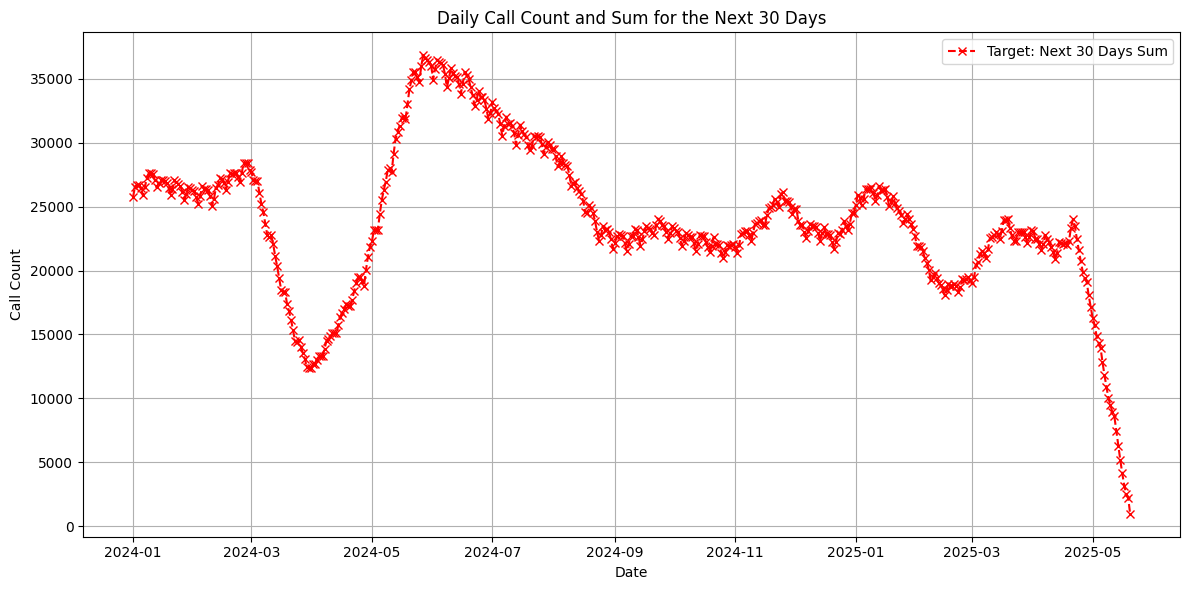

In [35]:
# 3. Plot the Data for Visual Verification
plt.figure(figsize=(12, 6))
plt.plot(
    daily_df_processed.index,
    daily_df_processed["target_next_30days"],
    marker="x",
    linestyle="--",
    color="red",
    label="Target: Next 30 Days Sum",
)
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.title("Daily Call Count and Sum for the Next 30 Days")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

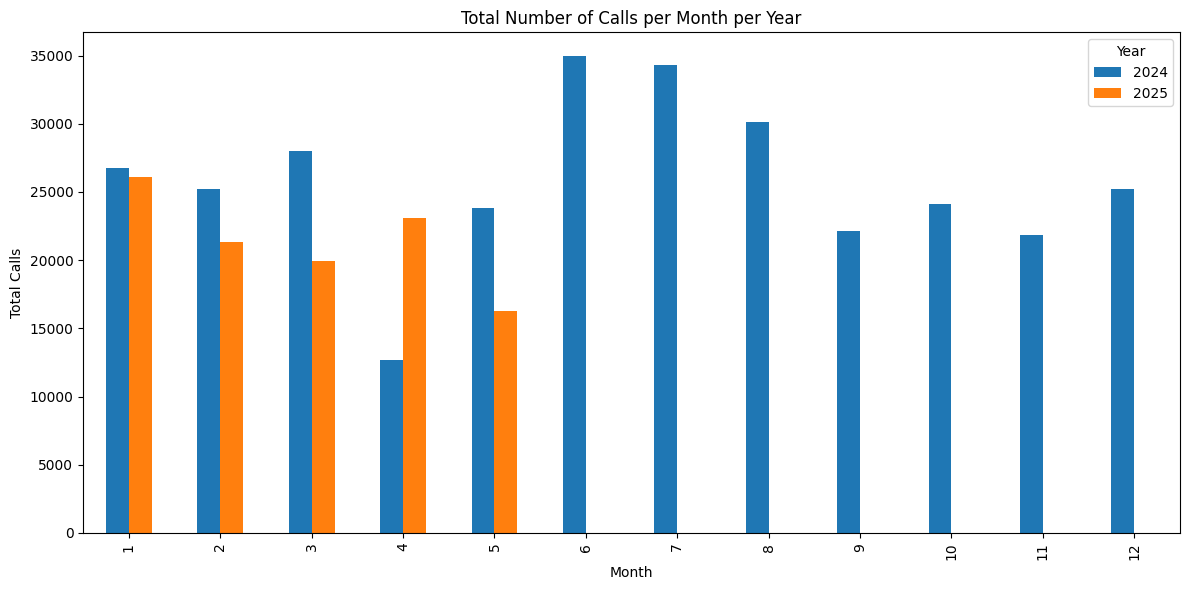

In [39]:
# Create year and month columns
daily_df_processed.reset_index(inplace=True)
daily_df_processed["year"] = daily_df_processed["date"].dt.year
daily_df_processed["month"] = daily_df_processed["date"].dt.month

# Aggregate total call_count per month per year
monthly_calls = (
    daily_df_processed.groupby(["year", "month"])["call_count"].sum().reset_index()
)

# Pivot the data for plotting
pivot_calls = monthly_calls.pivot(index="month", columns="year", values="call_count")

# Plot the total number of calls per month per year
pivot_calls.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Month")
plt.ylabel("Total Calls")
plt.title("Total Number of Calls per Month per Year")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

In [40]:
daily_df_processed.shape, df_processed.shape

((506, 22), (415901, 17))

In [42]:
daily_df_processed.reset_index(inplace=True)

In [43]:
df_processed[
    (df_processed["occurrence_date"] >= "2025-05-18 00:01")
    & (df_processed["occurrence_date"] <= "2025-05-19 00:01")
].shape

(304, 17)

In [44]:
df_processed[
    (df_processed["occurrence_date"] >= "2025-05-19 00:01")
    & (df_processed["occurrence_date"] <= "2025-05-20 00:01")
].shape

(1258, 17)

In [45]:
daily_df_processed[daily_df_processed["date"] > "2024-12-01"][
    ["date", "call_count", "target_next_30days"]
].tail(5)

,date,call_count,target_next_30days
501,2025-05-16,962,4140.0
502,2025-05-17,650,3178.0
503,2025-05-18,304,2528.0
504,2025-05-19,1258,2224.0
505,2025-05-20,966,966.0


## Holiday feature 

Although AutoML offers a built-in method to incorporate Brazilian holidays, we will develop a custom feature for this purpose to better tailor our analysis.

In [46]:
import pandas as pd
import holidays


def create_brazil_holiday_feature(df, date_col="date"):
    """
    Given a DataFrame containing a date column, this function adds a binary column 'is_brazil_holiday'
    that equals 1 if the date is a Brazilian holiday and 0 otherwise.
    Optionally, you can also store the holiday name.
    """
    # Ensure the date column is in datetime format.
    df[date_col] = pd.to_datetime(df[date_col])

    # Create a dictionary or use the holidays package to get Brazilian holidays.
    # Here, we'll get holidays for the years present in the data.
    years = df[date_col].dt.year.unique().tolist()
    br_holidays = holidays.Brazil(years=years)

    # Add a binary flag for whether each date is a Brazilian holiday.
    df["is_brazil_holiday"] = df[date_col].apply(lambda d: 1 if d in br_holidays else 0)

    # Optionally: add a column with the holiday name (or None if not a holiday)
    # df['brazil_holiday_name'] = df[date_col].apply(lambda d: br_holidays.get(d))

    return df

In [47]:
# Create the holiday feature.
daily_df_processed = create_brazil_holiday_feature(daily_df_processed, date_col="date")

## 🐍 Saving training and test data as first step in this notebook

In [49]:
# Divide daily_df_processed into train and test sets:
train = daily_df_processed[daily_df_processed["date"] < pd.Timestamp("2025-04-01")]
test = daily_df_processed[
    (daily_df_processed["date"] >= pd.Timestamp("2025-04-01"))
    & (daily_df_processed["date"] < pd.Timestamp("2025-05-01"))
]

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Train shape: (456, 24)
Test shape:  (30, 24)


In [80]:
c = ["level_0", "index", "year", "month"]

In [ ]:
for column in c:
    if column in train.columns:
        train.drop(columns=[column], inplace=True)
    if column in test.columns:
        test.drop(columns=[column], inplace=True)

In [85]:
train.to_csv("../data/silver/data_train_next_30days_count.csv", index=False)
test.to_csv("../data/silver/data_test_next_30days_count.csv", index=False)

paths = [
    {"file": "../data/silver/data_train_next_30days_count.csv"},
]

tbl = mltable.from_delimited_files(paths, infer_column_types=False)

# Set the column types for the 20 columns in the transformed dataset
column_types = {
    "time_to_resolve": DataType.to_float(),
    "closure_aberta_ca1-end_(tempo_de_contato_excedido)": DataType.to_int(),
    "closure_abertura": DataType.to_int(),
    "closure_desistencia": DataType.to_int(),
    "closure_direcionado": DataType.to_int(),
    "closure_liberado": DataType.to_int(),
    "closure_mdu_encaminhado_para_vistoria": DataType.to_int(),
    "closure_me_com_alteracao_de_pacote": DataType.to_int(),
    "closure_me_gerada": DataType.to_int(),
    "closure_me_n_gerada": DataType.to_int(),
    "closure_n_liberado": DataType.to_int(),
    "closure_outros": DataType.to_int(),
    "closure_queda_de_ligacao": DataType.to_int(),
    "closure_reencaminhado_para_vistoria": DataType.to_int(),
    "closure_timeout": DataType.to_int(),
    "closure_unknown": DataType.to_int(),
    "call_count": DataType.to_int(),
    "target_next_30days": DataType.to_float(),
    "is_brazil_holiday": DataType.to_int(),
}
tbl = tbl.convert_column_types(column_types)

In [ ]:
# save the MLTable to local disk - in the same directory as the titanic.csv file
tbl.save("../data/silver", overwrite=True)

### 🤝 Create a data asset to aid sharing and reproducibility

Your data (including the `MLTable` file) is currently saved on disk, making it hard to share with Team members. By creating a *data asset* in AzureML, your data will be uploaded to cloud storage and "bookmarked", meaning your Team members can access the MLTable using a friendly name. Also, the data asset is *versioned*.

In [ ]:
# set the version number of the data asset to the current UTC time
VERSION = time.strftime("%Y.%m.%d.%H%M%S", time.gmtime())

# connect to the AzureML workspace
ml_client = MLClient(
    DefaultAzureCredential(), subscription_id, resource_group, workspace
)

# create the data asset object
my_data = Data(
    path="../data/silver",
    type=AssetTypes.MLTABLE,
    description="Call Center Data",
    name="data_train_next_30days_count",
    version=VERSION,
)

# create the data asset in your workspace
ml_client.data.create_or_update(my_data)

In [94]:
# Loading back our saved MLTable
ml_client = MLClient(
    DefaultAzureCredential(), subscription_id, resource_group, workspace
)

data_asset = ml_client.data.get("call_center_data", version="2025.05.23.171812")

tbl = mltable.load(data_asset.path)

df = tbl.to_pandas_dataframe()

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [102]:
df.shape

(415901, 10)